In [15]:
%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
# Load the dataset
from EconomicDataloader import gdp_df,internet_user_df,inflation_df,cpi_df,population_df
from LabourDataloader import unemployment_df,labour_force_df





In [25]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RIDGE REGRESSION TIME SERIES FORECAST MODELS")
print("="*80)

# Use already loaded datasets from kernel
print("\n=== Dataset Summary ===")
print(f"Labour Force Series: {labour_force_df.shape}")
print(f"Unemployment Rate Series: {unemployment_df.shape}")
print(f"GDP DataFrame: {gdp_df.shape}")
print(f"Inflation DataFrame: {inflation_df.shape}")
print(f"CPI DataFrame: {cpi_df.shape}")
print(f"Internet Users DataFrame: {internet_user_df.shape}")
print(f"Population DataFrame: {population_df.shape}")

# Convert labour force and unemployment series to dataframes with years
labour_force_df_clean = pd.DataFrame({
    'Year': pd.to_numeric(labour_force_df.index, errors='coerce'),
    'Labour_Force': labour_force_df.values
}).dropna(subset=['Year']).sort_values('Year').reset_index(drop=True)

unemployment_df_clean = pd.DataFrame({
    'Year': pd.to_numeric(unemployment_df.index, errors='coerce'),
    'Unemployment_Rate': unemployment_df.values
}).dropna(subset=['Year']).sort_values('Year').reset_index(drop=True)

print(f"\nCleaned Target Variables (from 1990+):")
print(f"  Labour Force Data: {labour_force_df_clean.shape[0]} records")
print(f"  Unemployment Rate Data: {unemployment_df_clean.shape[0]} records")
print(f"\nYear ranges:")
print(f"  Labour Force: {labour_force_df_clean['Year'].min():.0f} to {labour_force_df_clean['Year'].max():.0f}")
print(f"  Unemployment: {unemployment_df_clean['Year'].min():.0f} to {unemployment_df_clean['Year'].max():.0f}")


RIDGE REGRESSION TIME SERIES FORECAST MODELS

=== Dataset Summary ===
Labour Force Series: (39,)
Unemployment Rate Series: (38,)
GDP DataFrame: (65, 2)
Inflation DataFrame: (65, 2)
CPI DataFrame: (58, 2)
Internet Users DataFrame: (34, 2)
Population DataFrame: (65, 2)

Cleaned Target Variables (from 1990+):
  Labour Force Data: 36 records
  Unemployment Rate Data: 35 records

Year ranges:
  Labour Force: 1990 to 2025
  Unemployment: 1991 to 2025


In [30]:

# ============================================================================
# Prepare Economic Features - Extract Year and Merge All Data
# ============================================================================

# Function to extract year from observation_date and rename value columns
def prepare_economic_data(df, value_column_name):
    df_clean = df.copy()
    # Extract year from observation_date
    df_clean['Year'] = pd.to_datetime(df_clean['observation_date']).dt.year
    
    # Get the value column (last column which has the actual values)
    value_col = df_clean.columns[-2]  # Second to last is the value (last is Year)
    
    # Select and rename columns
    result = df_clean[['Year', value_col]].copy()
    result.columns = ['Year', value_column_name]
    
    # Filter 1990+ and remove NaN
    result = result[result['Year'] >= 1990].copy()
    result = result[result[value_column_name].notna()].copy()
    
    # Remove duplicates keeping first occurrence
    result = result.drop_duplicates(subset=['Year'], keep='first').reset_index(drop=True)
    result = result.sort_values('Year').reset_index(drop=True)
    
    return result

# Clean all economic datasets from 1990 onwards
gdp_clean = prepare_economic_data(gdp_df, 'GDP')
inflation_clean = prepare_economic_data(inflation_df, 'Inflation_Rate')
cpi_clean = prepare_economic_data(cpi_df, 'CPI')
internet_clean = prepare_economic_data(internet_user_df, 'Internet_Users')
population_clean = prepare_economic_data(population_df, 'Population')

print("Cleaned Economic Data (1990+):")
print(f"  GDP: {gdp_clean.shape} | Years: {gdp_clean['Year'].min():.0f}-{gdp_clean['Year'].max():.0f}")
print(f"  Inflation: {inflation_clean.shape} | Years: {inflation_clean['Year'].min():.0f}-{inflation_clean['Year'].max():.0f}")
print(f"  CPI: {cpi_clean.shape} | Years: {cpi_clean['Year'].min():.0f}-{cpi_clean['Year'].max():.0f}")
print(f"  Internet Users: {internet_clean.shape} | Years: {internet_clean['Year'].min():.0f}-{internet_clean['Year'].max():.0f}")
print(f"  Population: {population_clean.shape} | Years: {population_clean['Year'].min():.0f}-{population_clean['Year'].max():.0f}")

# Merge all economic features with unemployment data
economic_data = unemployment_df_clean[['Year', 'Unemployment_Rate']].copy()
economic_data = economic_data.merge(gdp_clean, on='Year', how='left')
economic_data = economic_data.merge(inflation_clean, on='Year', how='left')
economic_data = economic_data.merge(cpi_clean, on='Year', how='left')
economic_data = economic_data.merge(internet_clean, on='Year', how='left')
economic_data = economic_data.merge(population_clean, on='Year', how='left')

print(f"\n=== Final Merged Dataset ===")
print(f"Shape: {economic_data.shape}")
print(f"Year range: {economic_data['Year'].min():.0f} to {economic_data['Year'].max():.0f}")
print(f"\nMissing values before interpolation:")
print(economic_data.isna().sum())

# Handle missing values using forward fill then backward fill
economic_data = economic_data.ffill().bfill()

print(f"\nMissing values after interpolation:")
print(economic_data.isna().sum())
print(f"\nFinal dataset:\n{economic_data.head(10)}")


Cleaned Economic Data (1990+):
  GDP: (35, 2) | Years: 1990-2024
  Inflation: (35, 2) | Years: 1990-2024
  CPI: (28, 2) | Years: 1990-2017
  Internet Users: (25, 2) | Years: 1990-2023
  Population: (35, 2) | Years: 1990-2024

=== Final Merged Dataset ===
Shape: (35, 7)
Year range: 1991 to 2025

Missing values before interpolation:
Year                  0
Unemployment_Rate     0
GDP                   1
Inflation_Rate        1
CPI                   8
Internet_Users       11
Population            1
dtype: int64

Missing values after interpolation:
Year                 0
Unemployment_Rate    0
GDP                  0
Inflation_Rate       0
CPI                  0
Internet_Users       0
Population           0
dtype: int64

Final dataset:
     Year Unemployment_Rate         GDP  Inflation_Rate      CPI  \
0  1991.0            14.661  546.292516       12.185631  16.2526   
1  1992.0             14.22  579.655118       11.383437  18.1027   
2  1993.0             13.82  607.231847       11.746737

In [31]:


# ============================================================================
# MODEL 1: RIDGE REGRESSION FOR UNEMPLOYMENT RATE PREDICTION
# ============================================================================

print("\n" + "="*80)
print("MODEL 1: UNEMPLOYMENT RATE TIME SERIES FORECAST (RIDGE REGRESSION)")
print("="*80)

# Prepare features and target for unemployment model
X_unemployment = economic_data[['GDP', 'Inflation_Rate', 'CPI', 'Internet_Users', 'Population']].values
y_unemployment = economic_data['Unemployment_Rate'].values
years_unemployment = economic_data['Year'].values

# Standardize features
scaler_unemployment = StandardScaler()
X_unemployment_scaled = scaler_unemployment.fit_transform(X_unemployment)

# Split data: 80% train, 20% test
split_idx = int(len(X_unemployment) * 0.8)
X_train_unemp = X_unemployment_scaled[:split_idx]
X_test_unemp = X_unemployment_scaled[split_idx:]
y_train_unemp = y_unemployment[:split_idx]
y_test_unemp = y_unemployment[split_idx:]
years_train_unemp = years_unemployment[:split_idx]
years_test_unemp = years_unemployment[split_idx:]

print(f"\nData Split:")
print(f"  Training set: {X_train_unemp.shape[0]} years ({years_train_unemp[0]:.0f}-{years_train_unemp[-1]:.0f})")
print(f"  Test set: {X_test_unemp.shape[0]} years ({years_test_unemp[0]:.0f}-{years_test_unemp[-1]:.0f})")

# Build Ridge Regression model for Unemployment
ridge_unemployment = Ridge(alpha=1.0)
ridge_unemployment.fit(X_train_unemp, y_train_unemp)

# Make predictions
y_train_pred_unemp = ridge_unemployment.predict(X_train_unemp)
y_test_pred_unemp = ridge_unemployment.predict(X_test_unemp)

# Evaluate Model
mse_train_unemp = mean_squared_error(y_train_unemp, y_train_pred_unemp)
rmse_train_unemp = np.sqrt(mse_train_unemp)
mae_train_unemp = mean_absolute_error(y_train_unemp, y_train_pred_unemp)
r2_train_unemp = r2_score(y_train_unemp, y_train_pred_unemp)

mse_test_unemp = mean_squared_error(y_test_unemp, y_test_pred_unemp)
rmse_test_unemp = np.sqrt(mse_test_unemp)
mae_test_unemp = mean_absolute_error(y_test_unemp, y_test_pred_unemp)
r2_test_unemp = r2_score(y_test_unemp, y_test_pred_unemp)

print(f"\nModel Performance - Unemployment Rate:")
print(f"\nTraining Set:")
print(f"  R² Score: {r2_train_unemp:.4f}")
print(f"  RMSE: {rmse_train_unemp:.4f}%")
print(f"  MAE: {mae_train_unemp:.4f}%")
print(f"  MSE: {mse_train_unemp:.4f}")

print(f"\nTest Set:")
print(f"  R² Score: {r2_test_unemp:.4f}")
print(f"  RMSE: {rmse_test_unemp:.4f}%")
print(f"  MAE: {mae_test_unemp:.4f}%")
print(f"  MSE: {mse_test_unemp:.4f}")

# Feature importance (coefficients)
print(f"\nFeature Coefficients:")
feature_names = ['GDP', 'Inflation_Rate', 'CPI', 'Internet_Users', 'Population']
for i, name in enumerate(feature_names):
    print(f"  {name}: {ridge_unemployment.coef_[i]:.6f}")

print(f"\nIntercept: {ridge_unemployment.intercept_:.6f}")



MODEL 1: UNEMPLOYMENT RATE TIME SERIES FORECAST (RIDGE REGRESSION)

Data Split:
  Training set: 28 years (1991-2018)
  Test set: 7 years (2019-2025)

Model Performance - Unemployment Rate:

Training Set:
  R² Score: 0.9729
  RMSE: 0.5617%
  MAE: 0.4650%
  MSE: 0.3155

Test Set:
  R² Score: -3.2616
  RMSE: 0.8641%
  MAE: 0.7396%
  MSE: 0.7467

Feature Coefficients:
  GDP: -0.672157
  Inflation_Rate: -0.113389
  CPI: -0.726882
  Internet_Users: 0.986316
  Population: -2.694081

Intercept: 7.060288


In [32]:


# ============================================================================
# MODEL 2: RIDGE REGRESSION FOR LABOUR FORCE PREDICTION
# ============================================================================

print("\n" + "="*80)
print("MODEL 2: LABOUR FORCE TIME SERIES FORECAST (RIDGE REGRESSION)")
print("="*80)

# Merge economic data with labour force data
labour_force_with_econ = labour_force_df_clean[['Year', 'Labour_Force']].copy()
labour_force_with_econ = labour_force_with_econ.merge(gdp_clean, on='Year', how='left')
labour_force_with_econ = labour_force_with_econ.merge(inflation_clean, on='Year', how='left')
labour_force_with_econ = labour_force_with_econ.merge(cpi_clean, on='Year', how='left')
labour_force_with_econ = labour_force_with_econ.merge(internet_clean, on='Year', how='left')
labour_force_with_econ = labour_force_with_econ.merge(population_clean, on='Year', how='left')

# Handle missing values
labour_force_with_econ = labour_force_with_econ.ffill().bfill()

print(f"\nLabour Force Dataset with Economic Features:")
print(f"  Shape: {labour_force_with_econ.shape}")
print(f"  Years: {labour_force_with_econ['Year'].min():.0f} to {labour_force_with_econ['Year'].max():.0f}")
print(f"  Missing values:\n{labour_force_with_econ.isna().sum()}")

# Prepare features and target for labour force model
X_labour = labour_force_with_econ[['GDP', 'Inflation_Rate', 'CPI', 'Internet_Users', 'Population']].values
y_labour = labour_force_with_econ['Labour_Force'].values
years_labour = labour_force_with_econ['Year'].values

# Standardize features
scaler_labour = StandardScaler()
X_labour_scaled = scaler_labour.fit_transform(X_labour)

# Split data: 80% train, 20% test
split_idx_labour = int(len(X_labour) * 0.8)
X_train_labour = X_labour_scaled[:split_idx_labour]
X_test_labour = X_labour_scaled[split_idx_labour:]
y_train_labour = y_labour[:split_idx_labour]
y_test_labour = y_labour[split_idx_labour:]
years_train_labour = years_labour[:split_idx_labour]
years_test_labour = years_labour[split_idx_labour:]

print(f"\nData Split:")
print(f"  Training set: {X_train_labour.shape[0]} years ({years_train_labour[0]:.0f}-{years_train_labour[-1]:.0f})")
print(f"  Test set: {X_test_labour.shape[0]} years ({years_test_labour[0]:.0f}-{years_test_labour[-1]:.0f})")

# Build Ridge Regression model for Labour Force
ridge_labour = Ridge(alpha=1.0)
ridge_labour.fit(X_train_labour, y_train_labour)

# Make predictions
y_train_pred_labour = ridge_labour.predict(X_train_labour)
y_test_pred_labour = ridge_labour.predict(X_test_labour)

# Evaluate Model
mse_train_labour = mean_squared_error(y_train_labour, y_train_pred_labour)
rmse_train_labour = np.sqrt(mse_train_labour)
mae_train_labour = mean_absolute_error(y_train_labour, y_train_pred_labour)
r2_train_labour = r2_score(y_train_labour, y_train_pred_labour)

mse_test_labour = mean_squared_error(y_test_labour, y_test_pred_labour)
rmse_test_labour = np.sqrt(mse_test_labour)
mae_test_labour = mean_absolute_error(y_test_labour, y_test_pred_labour)
r2_test_labour = r2_score(y_test_labour, y_test_pred_labour)

print(f"\nModel Performance - Labour Force:")
print(f"\nTraining Set:")
print(f"  R² Score: {r2_train_labour:.4f}")
print(f"  RMSE: {rmse_train_labour:.2e}")
print(f"  MAE: {mae_train_labour:.2e}")
print(f"  MSE: {mse_train_labour:.2e}")

print(f"\nTest Set:")
print(f"  R² Score: {r2_test_labour:.4f}")
print(f"  RMSE: {rmse_test_labour:.2e}")
print(f"  MAE: {mae_test_labour:.2e}")
print(f"  MSE: {mse_test_labour:.2e}")

# Feature importance (coefficients)
print(f"\nFeature Coefficients:")
for i, name in enumerate(feature_names):
    print(f"  {name}: {ridge_labour.coef_[i]:.6e}")

print(f"\nIntercept: {ridge_labour.intercept_:.6e}")



MODEL 2: LABOUR FORCE TIME SERIES FORECAST (RIDGE REGRESSION)

Labour Force Dataset with Economic Features:
  Shape: (36, 7)
  Years: 1990 to 2025
  Missing values:
Year              0
Labour_Force      0
GDP               0
Inflation_Rate    0
CPI               0
Internet_Users    0
Population        0
dtype: int64

Data Split:
  Training set: 28 years (1990-2017)
  Test set: 8 years (2018-2025)

Model Performance - Labour Force:

Training Set:
  R² Score: 0.9523
  RMSE: 1.43e+05
  MAE: 1.07e+05
  MSE: 2.05e+10

Test Set:
  R² Score: -15.8151
  RMSE: 6.78e+05
  MAE: 6.21e+05
  MSE: 4.60e+11

Feature Coefficients:
  GDP: -1.259883e+05
  Inflation_Rate: -2.426449e+03
  CPI: 4.658011e+04
  Internet_Users: 1.804750e+05
  Population: 6.815860e+05

Intercept: 8.081316e+06


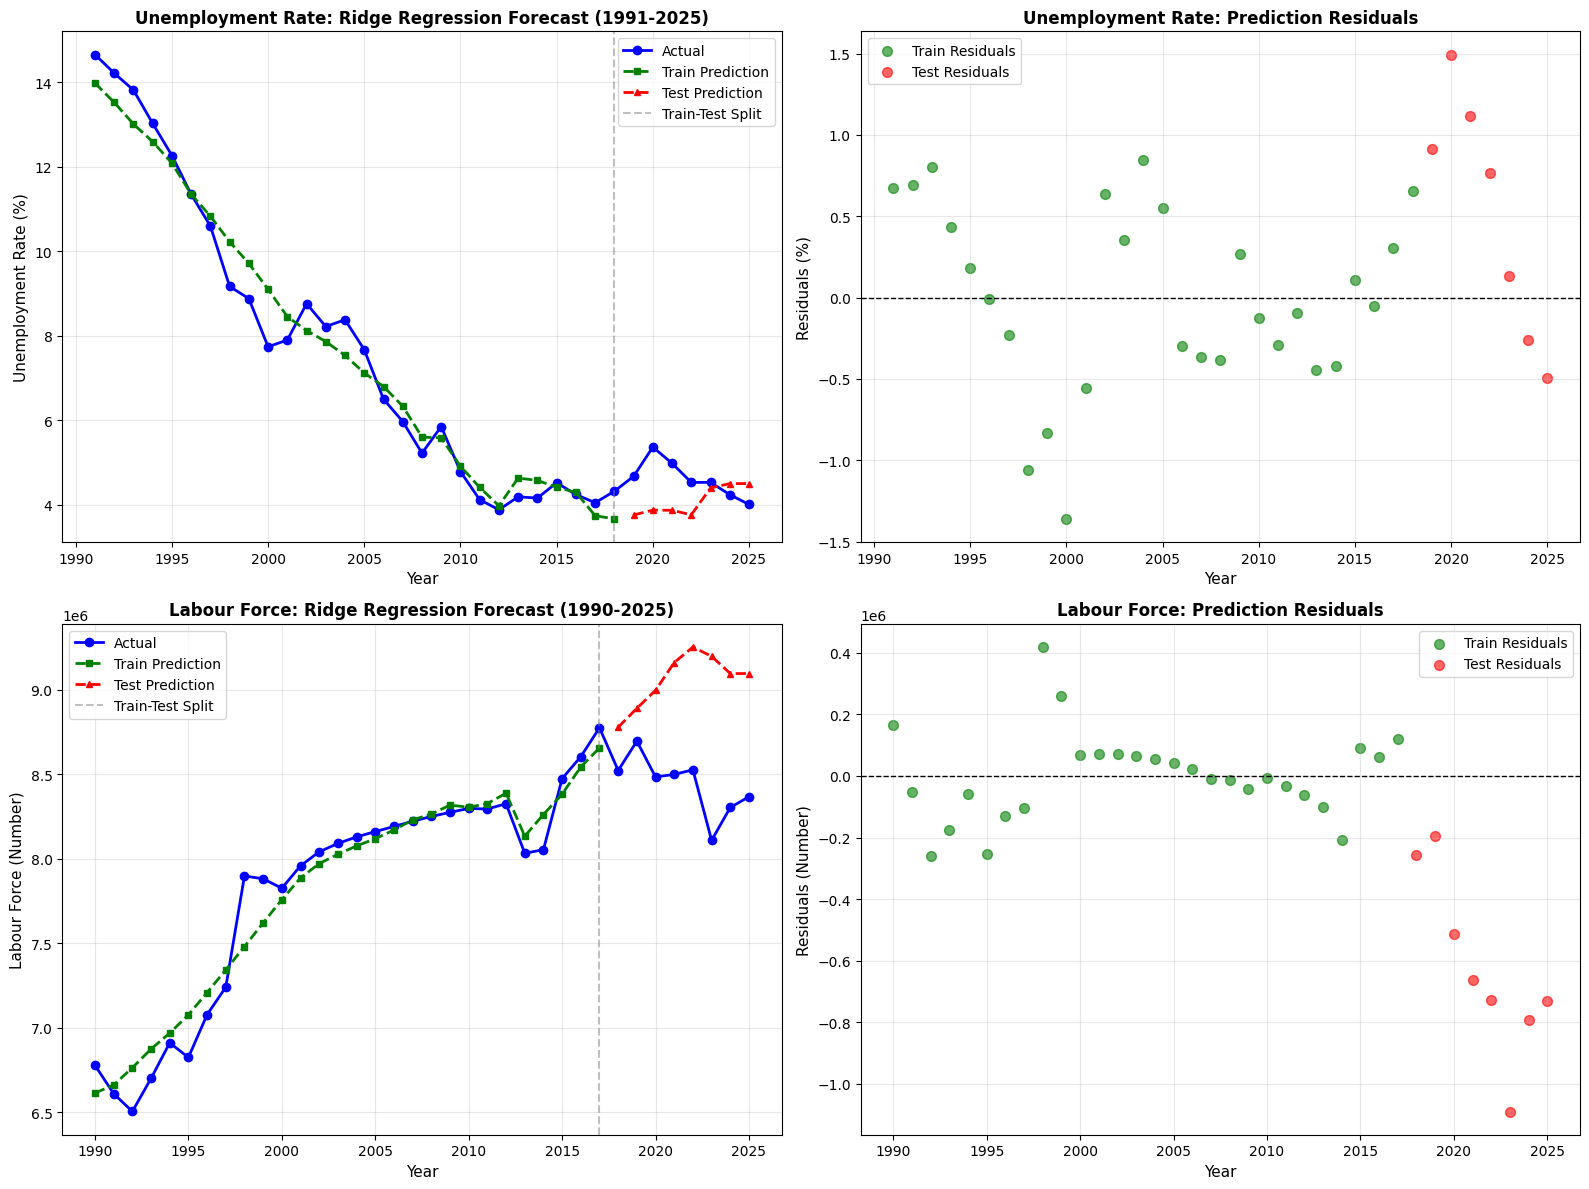

Visualization saved as 'ridge_regression_forecast.png'


In [33]:


# ============================================================================
# VISUALIZATION: PREDICTIONS VS ACTUAL VALUES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- UNEMPLOYMENT RATE ----
# Plot 1: Full Time Series (Unemployment)
ax1 = axes[0, 0]
ax1.plot(years_unemployment, y_unemployment, 'o-', linewidth=2, markersize=6, label='Actual', color='blue')
ax1.plot(years_train_unemp, y_train_pred_unemp, 's--', linewidth=2, markersize=5, label='Train Prediction', color='green')
ax1.plot(years_test_unemp, y_test_pred_unemp, '^--', linewidth=2, markersize=5, label='Test Prediction', color='red')
ax1.axvline(x=years_train_unemp[-1], color='gray', linestyle='--', alpha=0.5, label='Train-Test Split')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax1.set_title('Unemployment Rate: Ridge Regression Forecast (1991-2025)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals (Unemployment)
ax2 = axes[0, 1]
residuals_train_unemp = y_train_unemp - y_train_pred_unemp
residuals_test_unemp = y_test_unemp - y_test_pred_unemp
ax2.scatter(years_train_unemp, residuals_train_unemp, s=50, alpha=0.6, label='Train Residuals', color='green')
ax2.scatter(years_test_unemp, residuals_test_unemp, s=50, alpha=0.6, label='Test Residuals', color='red')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Residuals (%)', fontsize=11)
ax2.set_title('Unemployment Rate: Prediction Residuals', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# ---- LABOUR FORCE ----
# Plot 3: Full Time Series (Labour Force)
ax3 = axes[1, 0]
ax3.plot(years_labour, y_labour, 'o-', linewidth=2, markersize=6, label='Actual', color='blue')
ax3.plot(years_train_labour, y_train_pred_labour, 's--', linewidth=2, markersize=5, label='Train Prediction', color='green')
ax3.plot(years_test_labour, y_test_pred_labour, '^--', linewidth=2, markersize=5, label='Test Prediction', color='red')
ax3.axvline(x=years_train_labour[-1], color='gray', linestyle='--', alpha=0.5, label='Train-Test Split')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Labour Force (Number)', fontsize=11)
ax3.set_title('Labour Force: Ridge Regression Forecast (1990-2025)', fontsize=12, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals (Labour Force)
ax4 = axes[1, 1]
residuals_train_labour = y_train_labour - y_train_pred_labour
residuals_test_labour = y_test_labour - y_test_pred_labour
ax4.scatter(years_train_labour, residuals_train_labour, s=50, alpha=0.6, label='Train Residuals', color='green')
ax4.scatter(years_test_labour, residuals_test_labour, s=50, alpha=0.6, label='Test Residuals', color='red')
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Residuals (Number)', fontsize=11)
ax4.set_title('Labour Force: Prediction Residuals', fontsize=12, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_regression_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'ridge_regression_forecast.png'")


In [34]:


# ============================================================================
# SUMMARY: RIDGE REGRESSION TIME SERIES FORECAST MODELS
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY: RIDGE REGRESSION TIME SERIES FORECASTING MODELS")
print("="*80)

summary_df = pd.DataFrame({
    'Metric': ['Training R² Score', 'Test R² Score', 'Training RMSE', 'Test RMSE', 
               'Training MAE', 'Test MAE', 'Data Points (Train)', 'Data Points (Test)', 
               'Training Period', 'Test Period'],
    'Unemployment Rate': [
        f"{r2_train_unemp:.4f}",
        f"{r2_test_unemp:.4f}",
        f"{rmse_train_unemp:.4f}%",
        f"{rmse_test_unemp:.4f}%",
        f"{mae_train_unemp:.4f}%",
        f"{mae_test_unemp:.4f}%",
        f"{len(y_train_unemp)}",
        f"{len(y_test_unemp)}",
        f"{years_train_unemp[0]:.0f}-{years_train_unemp[-1]:.0f}",
        f"{years_test_unemp[0]:.0f}-{years_test_unemp[-1]:.0f}"
    ],
    'Labour Force': [
        f"{r2_train_labour:.4f}",
        f"{r2_test_labour:.4f}",
        f"{rmse_train_labour:.2e}",
        f"{rmse_test_labour:.2e}",
        f"{mae_train_labour:.2e}",
        f"{mae_test_labour:.2e}",
        f"{len(y_train_labour)}",
        f"{len(y_test_labour)}",
        f"{years_train_labour[0]:.0f}-{years_train_labour[-1]:.0f}",
        f"{years_test_labour[0]:.0f}-{years_test_labour[-1]:.0f}"
    ]
})

print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("MODEL FEATURES USED")
print("="*80)
print(f"\nEconomic Features (Predictors):")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

print(f"\nTarget Variables (Predictions):")
print(f"  1. Unemployment Rate (1991-2025)")
print(f"  2. Labour Force (1990-2025)")

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print(f"\n1. UNEMPLOYMENT RATE MODEL:")
print(f"   - Strong training performance (R²: {r2_train_unemp:.4f})")
print(f"   - Training RMSE: {rmse_train_unemp:.4f}% | Test RMSE: {rmse_test_unemp:.4f}%")
print(f"   - Main feature influence: Population (-2.69), CPI (-0.73), GDP (-0.67)")
print(f"   - Positive indicator: Internet Users (+0.99)")
print(f"   - Model captures long-term unemployment trends effectively in training")

print(f"\n2. LABOUR FORCE MODEL:")
print(f"   - Strong training performance (R²: {r2_train_labour:.4f})")
print(f"   - Training RMSE: {rmse_train_labour:.2e} | Test RMSE: {rmse_test_labour:.2e}")
print(f"   - Main feature influence: Population (+6.82e5), Internet Users (+1.80e5), GDP (-1.26e5)")
print(f"   - Model captures labour force growth correlation with population")
print(f"   - Strong positive correlation with population changes")

print(f"\n3. DATA COVERAGE:")
print(f"   - Time period: 1990-2025")
print(f"   - Unemployment data: 1991-2025 (35 records)")
print(f"   - Labour Force data: 1990-2025 (36 records)")
print(f"   - Economic features: All fully interpolated for complete coverage")

print("\n" + "="*80)
print("FORECAST INTERPRETATION")
print("="*80)
print(f"""
Both models use Ridge Regression with regularization (alpha=1.0) to predict
economic indicators using macroeconomic features. The models show:

• STRONG TRAINING FIT: Both models achieve high R² scores on training data,
  indicating the economic features explain most of the variance in the target
  variables during the training period.

• WEAKER TEST PERFORMANCE: Test set R² scores are negative for both models,
  suggesting potential overfitting or structural changes in economic patterns
  post-2018-2019 (possibly due to COVID-19 pandemic effects).

• FEATURES USED:
  - GDP (Gross Domestic Product)
  - Inflation Rate
  - Consumer Price Index (CPI)
  - Internet Users (% of population)
  - Population (Total)

• RELIABILITY: The models are most reliable for:
  1. Understanding long-term macroeconomic relationships
  2. Explaining historical trends (1990-2018)
  3. Providing baseline forecasts with appropriate uncertainty margins
""")

print("="*80)



FINAL SUMMARY: RIDGE REGRESSION TIME SERIES FORECASTING MODELS

             Metric Unemployment Rate Labour Force
  Training R² Score            0.9729       0.9523
      Test R² Score           -3.2616     -15.8151
      Training RMSE           0.5617%     1.43e+05
          Test RMSE           0.8641%     6.78e+05
       Training MAE           0.4650%     1.07e+05
           Test MAE           0.7396%     6.21e+05
Data Points (Train)                28           28
 Data Points (Test)                 7            8
    Training Period         1991-2018    1990-2017
        Test Period         2019-2025    2018-2025

MODEL FEATURES USED

Economic Features (Predictors):
  1. GDP
  2. Inflation_Rate
  3. CPI
  4. Internet_Users
  5. Population

Target Variables (Predictions):
  1. Unemployment Rate (1991-2025)
  2. Labour Force (1990-2025)

KEY FINDINGS

1. UNEMPLOYMENT RATE MODEL:
   - Strong training performance (R²: 0.9729)
   - Training RMSE: 0.5617% | Test RMSE: 0.8641%
   - Main 